Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.800/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.800/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.400/center_box/cavitation_initial.gsd


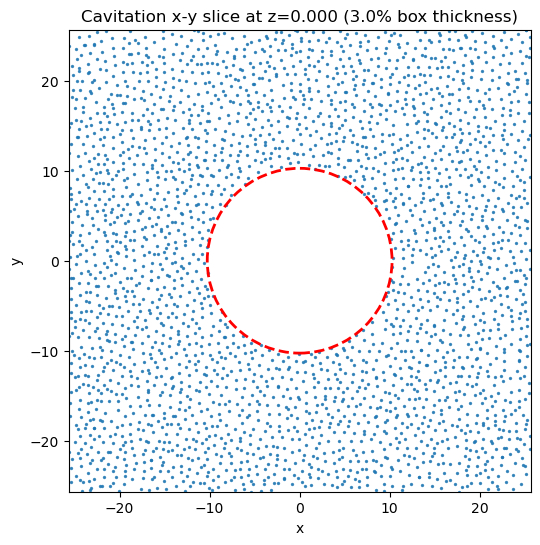

In [95]:
from md_Helpers import cavitation as cav
from md_Helpers import runs, visualization as vh
import importlib
from md_Helpers import visualization as vh
importlib.reload(vh)


initial = cav.get_or_create_cavitation_state(
    n_fcc_cells=20,
    target_rho=0.800,
    kT=0.800,
    source_nsteps=1_000_000,
    source_seed=1,
    source_phase_name="randomization",

    radius_fraction=0.4,
    random_location=False,
    bubble_seed=1,

    require_existing_source=True,
    overwrite=False,
)

initial["paths"]
initial["creation_info"]

vh.plot_cavitation_xy_slice(
    initial,
    fraction=0.03,
    point_size=2,
    alpha=0.8,
    show_bubble=True,
)

In [96]:
import importlib
from md_Helpers import cavitation as cav
from md_Helpers import runs

importlib.reload(runs)
importlib.reload(cav)

evolution = cav.get_or_create_cavitation(
    n_fcc_cells=20,
    target_rho=0.72,
    kT=0.80,
    source_nsteps=1_000_000,
    radius_fraction=0.5,
    evolve_nsteps=100_000,
)

No source thermalized state found for the specified values.
n_fcc_cells       = 20
target_rho        = 0.72
kT                = 0.8
source_nsteps     = 1000000
source_seed       = 1
source_phase_name = randomization

Missing paths:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_20/rho_0.720/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_20/rho_0.720/kT_0.800/nsteps_1000000/seed_1/randomization_log.hdf5


FileNotFoundError: No source thermalized state exists for the specified values. Run/create the source randomization state first.

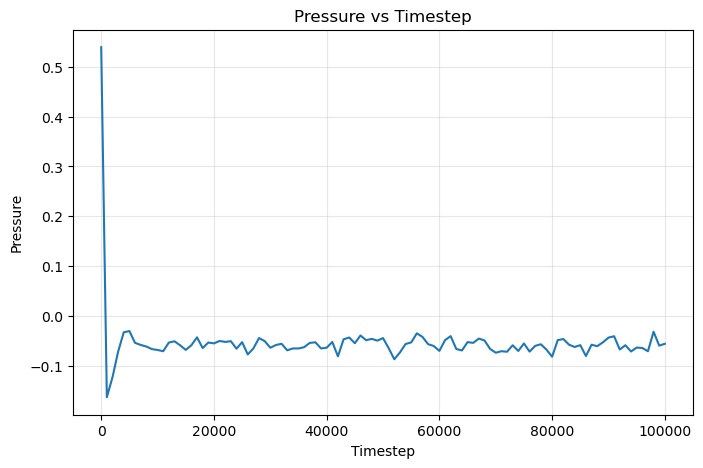

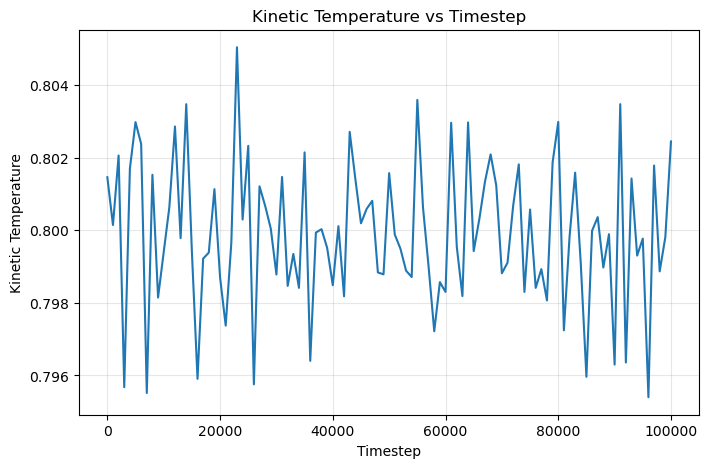

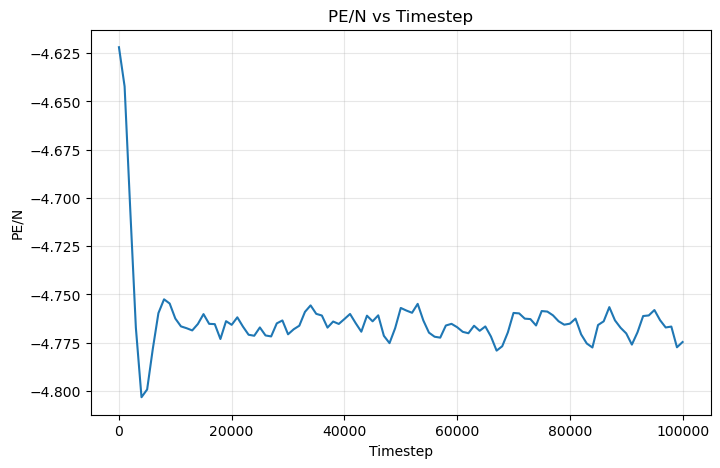

In [90]:
log_path = evolution["paths"]["log_path"]
log = runs.read_hdf5_log(log_path)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_temperature")
vh.plot_log_quantity(log, "potential_energy")

In [91]:
from md_Helpers import visualization as vh

trajectory_path = evolution["paths"]["trajectory_path"]
center_z = evolution["initial_result"]["creation_info"].get("bubble_center_z", 0.0)

vh.animate_xy_slice_trajectory(
    trajectory_path,
    fraction=0.03,
    max_frames=100,
    interval=120,
)

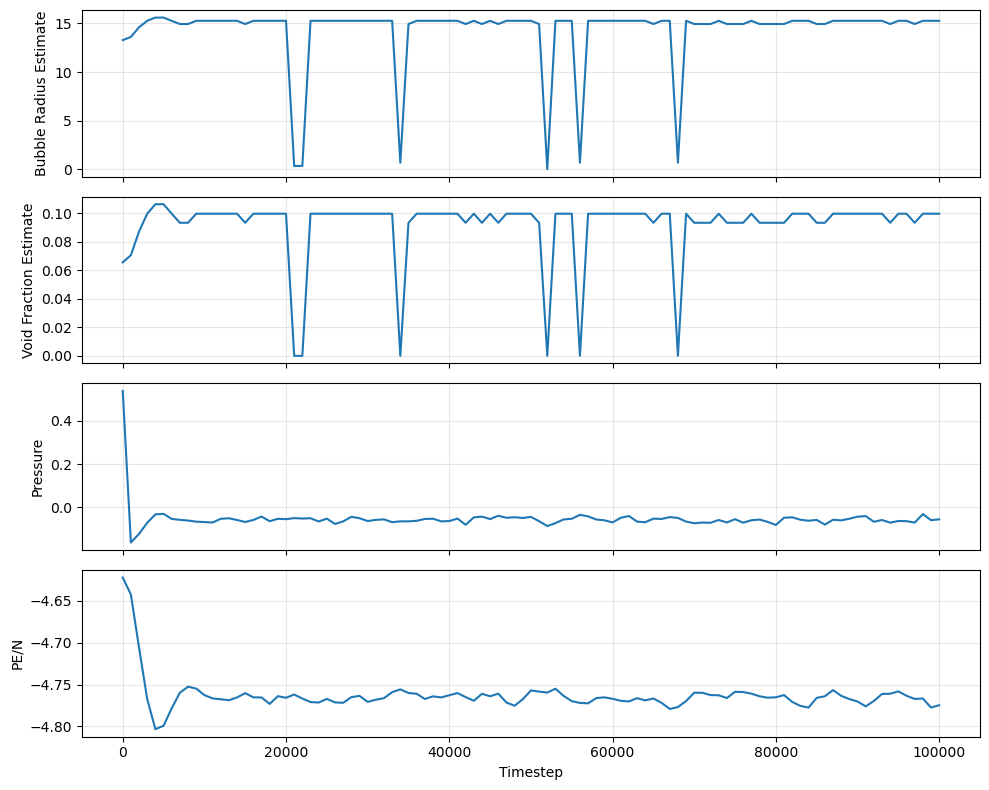

In [94]:
import importlib
from md_Helpers import cavitation as cav
from md_Helpers import visualization as vh

importlib.reload(cav)
importlib.reload(vh)

measurements = cav.measure_cavitation_trajectory(
    evolution,
    n_radial_bins=80,
    density_threshold_fraction=0.5,
    save_csv_path=evolution["paths"]["folder"] / "cavitation_measurements.csv",
)
vh.plot_cavitation_measurements(measurements)

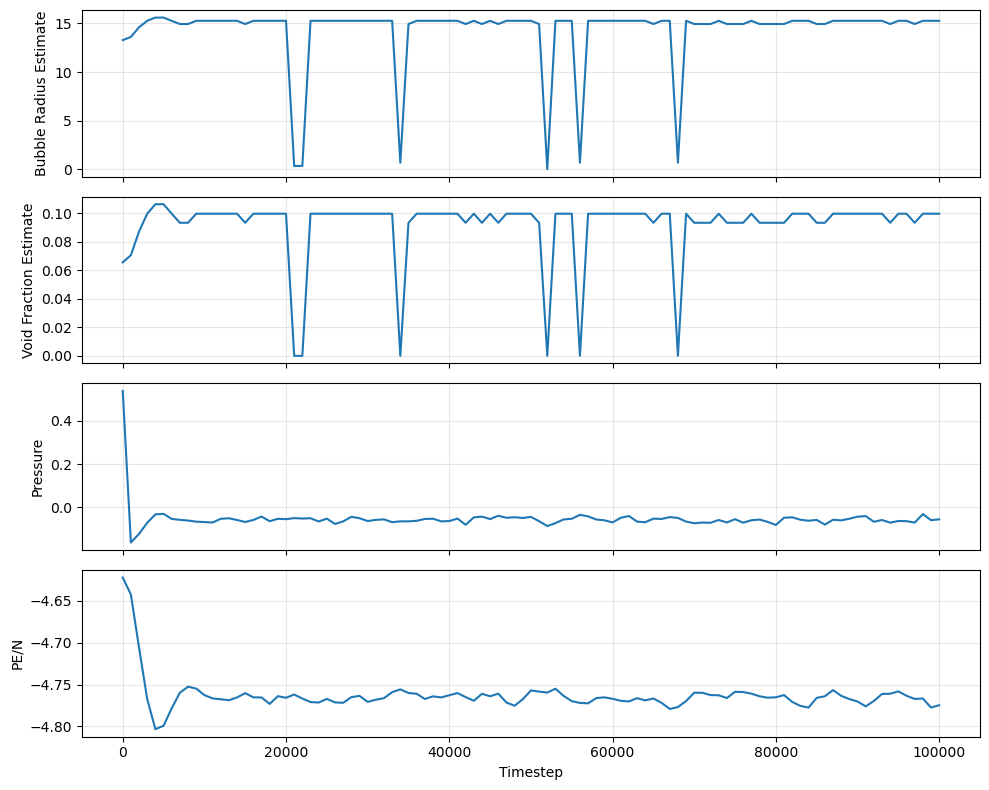

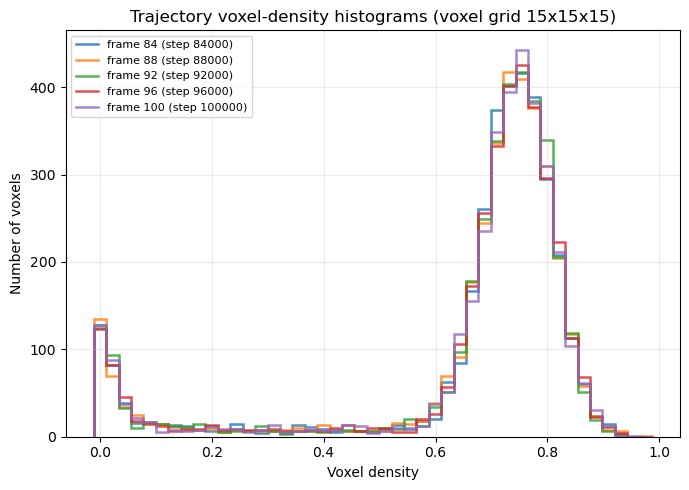

[{'frame_index': 84,
  'timestep': 84000,
  'mean_density': 0.6630150486633622,
  'std_density': 0.22564207264061265,
  'min_density': 0.0,
  'max_density': 0.9318749382569839,
  'empty_voxels': 128},
 {'frame_index': 88,
  'timestep': 88000,
  'mean_density': 0.6630150486633622,
  'std_density': 0.2241759402209523,
  'min_density': 0.0,
  'max_density': 0.9762499353168403,
  'empty_voxels': 135},
 {'frame_index': 92,
  'timestep': 92000,
  'mean_density': 0.6630150486633622,
  'std_density': 0.22518768538934178,
  'min_density': 0.0,
  'max_density': 0.9318749382569839,
  'empty_voxels': 124},
 {'frame_index': 96,
  'timestep': 96000,
  'mean_density': 0.6630150486633622,
  'std_density': 0.22557610739513415,
  'min_density': 0.0,
  'max_density': 0.9318749382569839,
  'empty_voxels': 123},
 {'frame_index': 100,
  'timestep': 100000,
  'mean_density': 0.6630150486633622,
  'std_density': 0.22594836432470966,
  'min_density': 0.0,
  'max_density': 0.954062436786912,
  'empty_voxels': 1

In [73]:
import importlib
from md_Helpers import visualization as vh

importlib.reload(vh)

voxel_hist = vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=15,
    last_n=5,
    skip=4,
    histogram_bins="shared_counts",
    normalize=False,
)

voxel_hist["selected_frame_indices"]
voxel_hist["summary"]

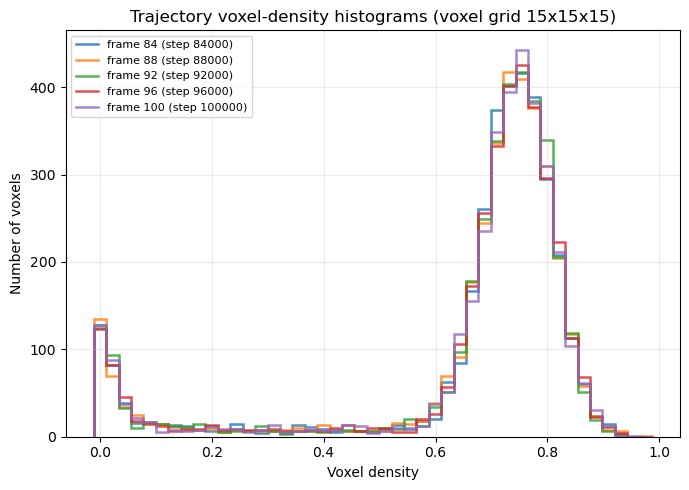

{'trajectory_path': '/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.500/center_box/evolve_kT_0.800/nsteps_100000/seed_1/cavitation_trajectory.gsd',
 'selected_frame_indices': [84, 88, 92, 96, 100],
 'summary': [{'frame_index': 84,
   'timestep': 84000,
   'mean_density': 0.6630150486633622,
   'std_density': 0.22564207264061265,
   'min_density': 0.0,
   'max_density': 0.9318749382569839,
   'empty_voxels': 128},
  {'frame_index': 88,
   'timestep': 88000,
   'mean_density': 0.6630150486633622,
   'std_density': 0.2241759402209523,
   'min_density': 0.0,
   'max_density': 0.9762499353168403,
   'empty_voxels': 135},
  {'frame_index': 92,
   'timestep': 92000,
   'mean_density': 0.6630150486633622,
   'std_density': 0.22518768538934178,
   'min_density': 0.0,
   'max_density': 0.9318749382569839,
   'empty_voxels': 124},
  {'frame_index': 96,
   'timestep'

In [74]:
vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=15,
    last_n=5,
    skip=4,
)

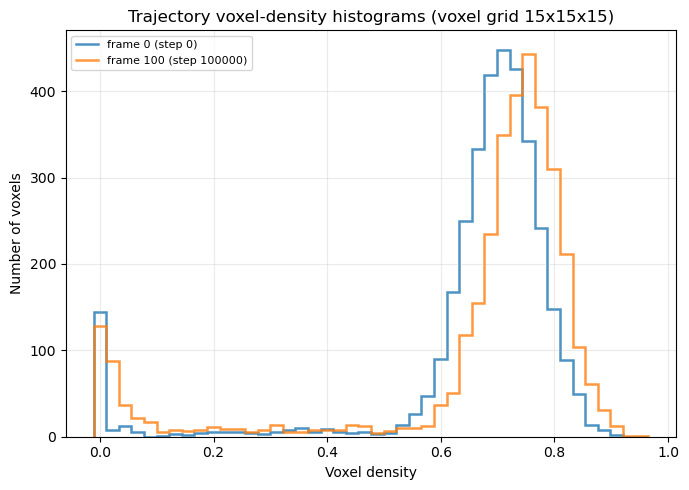

{'trajectory_path': '/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.500/center_box/evolve_kT_0.800/nsteps_100000/seed_1/cavitation_trajectory.gsd',
 'selected_frame_indices': [0, 100],
 'summary': [{'frame_index': 0,
   'timestep': 0,
   'mean_density': 0.6630150486633622,
   'std_density': 0.17465788889171005,
   'min_density': 0.0,
   'max_density': 0.9096874397270557,
   'empty_voxels': 144},
  {'frame_index': 100,
   'timestep': 100000,
   'mean_density': 0.6630150486633622,
   'std_density': 0.22594836432470966,
   'min_density': 0.0,
   'max_density': 0.954062436786912,
   'empty_voxels': 128}],
 'density_edges': array([-0.01109375,  0.01109375,  0.03328125,  0.05546875,  0.07765624,
         0.09984374,  0.12203124,  0.14421874,  0.16640624,  0.18859374,
         0.21078124,  0.23296873,  0.25515623,  0.27734373,  0.29953123,
         0.32171873,  

In [75]:
vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=15,
    frame_indices=[0,-1],
)